In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

import torchvision
import torchvision.transforms as transforms

import matplotlib.pyplot as plt
import numpy as np

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [ ]:
SAVE_PATH = "D:\\Tredence\\output"

In [5]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=128,
                                          shuffle=True)

testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)

testloader = torch.utils.data.DataLoader(testset, batch_size=128,
                                         shuffle=False)

In [6]:
class PrunableLinear(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()
        
        self.weight = nn.Parameter(torch.randn(out_features, in_features) * 0.01)
        self.bias = nn.Parameter(torch.zeros(out_features))
        
        self.gate_scores = nn.Parameter(torch.randn(out_features, in_features))

    def forward(self, x):
        gates = torch.sigmoid(self.gate_scores)
        pruned_weights = self.weight * gates
        return F.linear(x, pruned_weights, self.bias)

In [7]:
class PrunableMLP(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.fc1 = PrunableLinear(32*32*3, 512)
        self.fc2 = PrunableLinear(512, 256)
        self.fc3 = PrunableLinear(256, 10)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [8]:
def compute_sparsity_loss(model):
    sparsity_loss = 0
    
    for module in model.modules():
        if isinstance(module, PrunableLinear):
            gates = torch.sigmoid(module.gate_scores)
            sparsity_loss += torch.sum(gates)
    
    return sparsity_loss

In [9]:
def evaluate_accuracy(model, testloader):
    model.eval()
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in testloader:
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    return 100 * correct / total

In [10]:
def calculate_sparsity(model, threshold=1e-2):
    total = 0
    pruned = 0
    
    for module in model.modules():
        if isinstance(module, PrunableLinear):
            gates = torch.sigmoid(module.gate_scores)
            
            total += gates.numel()
            pruned += (gates < threshold).sum().item()
    
    return 100 * pruned / total

In [11]:
def plot_gate_distribution(model):
    all_gates = []
    
    for module in model.modules():
        if isinstance(module, PrunableLinear):
            gates = torch.sigmoid(module.gate_scores).detach().cpu().numpy()
            all_gates.extend(gates.flatten())
    
    plt.hist(all_gates, bins=50)
    plt.title("Gate Value Distribution")
    plt.xlabel("Gate Values")
    plt.ylabel("Frequency")
    plt.show()

In [12]:
def init_logs():
    return {
        "train_loss": [],
        "classification_loss": [],
        "sparsity_loss": [],
        "accuracy": [],
        "sparsity": []
    }

In [13]:
def train_epoch(model, trainloader, optimizer, lambda_):
    model.train()
    
    total_loss = 0
    total_cls = 0
    total_sparse = 0
    
    for images, labels in trainloader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        
        outputs = model(images)
        cls_loss = F.cross_entropy(outputs, labels)
        sparse_loss = compute_sparsity_loss(model)
        
        loss = cls_loss + lambda_ * sparse_loss
        
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        total_cls += cls_loss.item()
        total_sparse += sparse_loss.item()
    
    return total_loss/len(trainloader), total_cls/len(trainloader), total_sparse/len(trainloader)

In [14]:
def train_model(lambda_, epochs=30):
    model = PrunableMLP().to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    logs = init_logs()
    
    for epoch in range(epochs):
        loss, cls_loss, sparse_loss = train_epoch(model, trainloader, optimizer, lambda_)
        
        acc = evaluate_accuracy(model, testloader)
        sparsity = calculate_sparsity(model)
        
        logs["train_loss"].append(loss)
        logs["classification_loss"].append(cls_loss)
        logs["sparsity_loss"].append(sparse_loss)
        logs["accuracy"].append(acc)
        logs["sparsity"].append(sparsity)
        
        print(f"Epoch {epoch+1}: Loss={loss:.4f}, Acc={acc:.2f}, Sparsity={sparsity:.2f}")
    
    return model, logs

In [15]:
import json

def save_logs(logs, filename):
    with open(filename, "w") as f:
        json.dump(logs, f)

In [16]:
def plot_logs(logs, save_path=None):
    epochs = range(1, len(logs["accuracy"]) + 1)
    
    plt.figure(figsize=(12,5))
    
    plt.subplot(1,2,1)
    plt.plot(epochs, logs["accuracy"])
    plt.title("Accuracy vs Epoch")
    
    plt.subplot(1,2,2)
    plt.plot(epochs, logs["sparsity"])
    plt.title("Sparsity vs Epoch")
    
    if save_path:
        plt.savefig(save_path)
    
    plt.show()


===== Training lambda = 1e-05 =====
Epoch 1: Loss=9.5936, Acc=45.70, Sparsity=0.00
Epoch 2: Loss=8.1713, Acc=49.46, Sparsity=0.00
Epoch 3: Loss=7.0714, Acc=52.25, Sparsity=0.01
Epoch 4: Loss=6.1847, Acc=53.68, Sparsity=0.02
Epoch 5: Loss=5.4792, Acc=53.52, Sparsity=0.04
Epoch 6: Loss=4.9192, Acc=54.58, Sparsity=0.07
Epoch 7: Loss=4.4709, Acc=56.01, Sparsity=0.12
Epoch 8: Loss=4.1110, Acc=55.29, Sparsity=0.20
Epoch 9: Loss=3.8159, Acc=55.71, Sparsity=0.30
Epoch 10: Loss=3.5691, Acc=55.61, Sparsity=0.45
Epoch 11: Loss=3.3570, Acc=55.53, Sparsity=0.65
Epoch 12: Loss=3.1755, Acc=56.01, Sparsity=0.90
Epoch 13: Loss=3.0129, Acc=56.19, Sparsity=1.23
Epoch 14: Loss=2.8671, Acc=55.20, Sparsity=1.64
Epoch 15: Loss=2.7367, Acc=55.77, Sparsity=2.14
Epoch 16: Loss=2.6189, Acc=56.14, Sparsity=2.73
Epoch 17: Loss=2.5136, Acc=55.78, Sparsity=3.43
Epoch 18: Loss=2.4124, Acc=55.46, Sparsity=4.24
Epoch 19: Loss=2.3235, Acc=55.64, Sparsity=5.16
Epoch 20: Loss=2.2402, Acc=55.34, Sparsity=6.21
Epoch 21: Lo

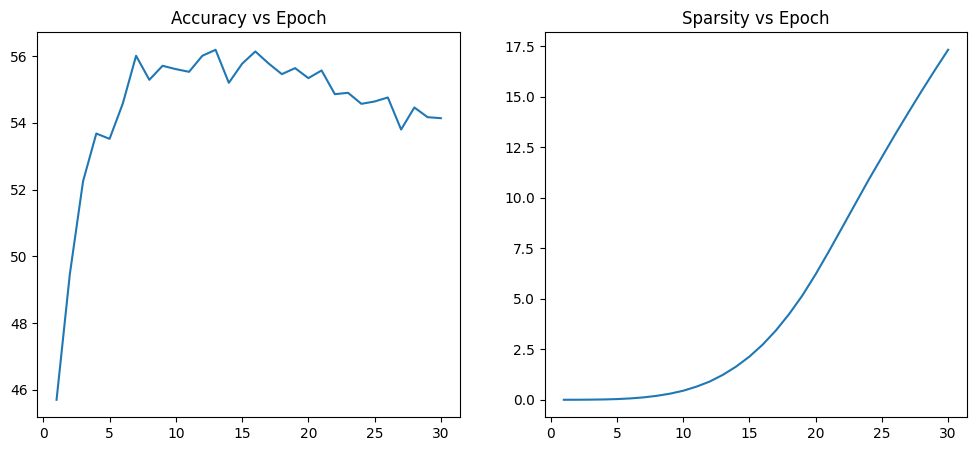


===== Training lambda = 0.0001 =====
Epoch 1: Loss=80.2242, Acc=46.70, Sparsity=0.00
Epoch 2: Loss=66.7096, Acc=49.45, Sparsity=0.00
Epoch 3: Loss=54.4310, Acc=51.62, Sparsity=0.01
Epoch 4: Loss=43.8181, Acc=53.29, Sparsity=0.03
Epoch 5: Loss=35.1056, Acc=53.93, Sparsity=0.07
Epoch 6: Loss=28.2308, Acc=55.06, Sparsity=0.16
Epoch 7: Loss=22.9351, Acc=55.12, Sparsity=0.29
Epoch 8: Loss=18.8832, Acc=55.42, Sparsity=0.52
Epoch 9: Loss=15.7774, Acc=55.91, Sparsity=0.89
Epoch 10: Loss=13.3671, Acc=56.74, Sparsity=1.43
Epoch 11: Loss=11.4804, Acc=56.28, Sparsity=2.22
Epoch 12: Loss=9.9837, Acc=56.11, Sparsity=3.35
Epoch 13: Loss=8.7832, Acc=56.40, Sparsity=4.87
Epoch 14: Loss=7.8072, Acc=56.53, Sparsity=6.88
Epoch 15: Loss=7.0076, Acc=56.67, Sparsity=9.45
Epoch 16: Loss=6.3454, Acc=56.21, Sparsity=12.66
Epoch 17: Loss=5.7922, Acc=56.75, Sparsity=16.56
Epoch 18: Loss=5.3241, Acc=56.57, Sparsity=21.22
Epoch 19: Loss=4.9281, Acc=56.97, Sparsity=26.59
Epoch 20: Loss=4.5864, Acc=56.69, Sparsity=3

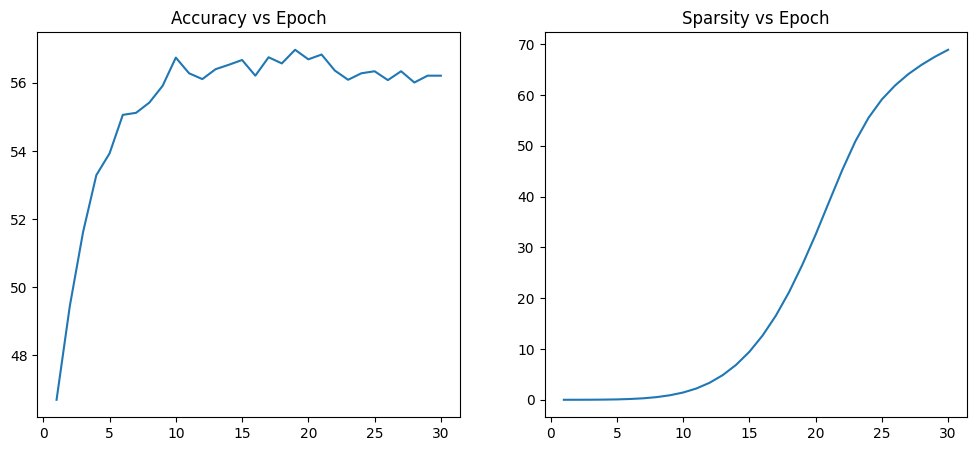


===== Training lambda = 0.0005 =====
Epoch 1: Loss=394.1489, Acc=45.60, Sparsity=0.00
Epoch 2: Loss=327.0936, Acc=49.45, Sparsity=0.00
Epoch 3: Loss=265.3948, Acc=51.09, Sparsity=0.01
Epoch 4: Loss=211.6431, Acc=52.00, Sparsity=0.03
Epoch 5: Loss=167.1915, Acc=53.98, Sparsity=0.08
Epoch 6: Loss=131.9189, Acc=53.79, Sparsity=0.16
Epoch 7: Loss=104.6258, Acc=55.00, Sparsity=0.32
Epoch 8: Loss=83.6998, Acc=54.45, Sparsity=0.59
Epoch 9: Loss=67.6249, Acc=55.03, Sparsity=1.01
Epoch 10: Loss=55.1727, Acc=55.33, Sparsity=1.68
Epoch 11: Loss=45.4254, Acc=54.17, Sparsity=2.70
Epoch 12: Loss=37.7099, Acc=55.02, Sparsity=4.18
Epoch 13: Loss=31.5452, Acc=55.37, Sparsity=6.31
Epoch 14: Loss=26.5726, Acc=55.80, Sparsity=9.24
Epoch 15: Loss=22.5322, Acc=55.99, Sparsity=13.21
Epoch 16: Loss=19.2263, Acc=55.65, Sparsity=18.38
Epoch 17: Loss=16.5051, Acc=55.80, Sparsity=24.93
Epoch 18: Loss=14.2560, Acc=56.03, Sparsity=32.99
Epoch 19: Loss=12.3893, Acc=55.47, Sparsity=42.61
Epoch 20: Loss=10.8331, Acc=

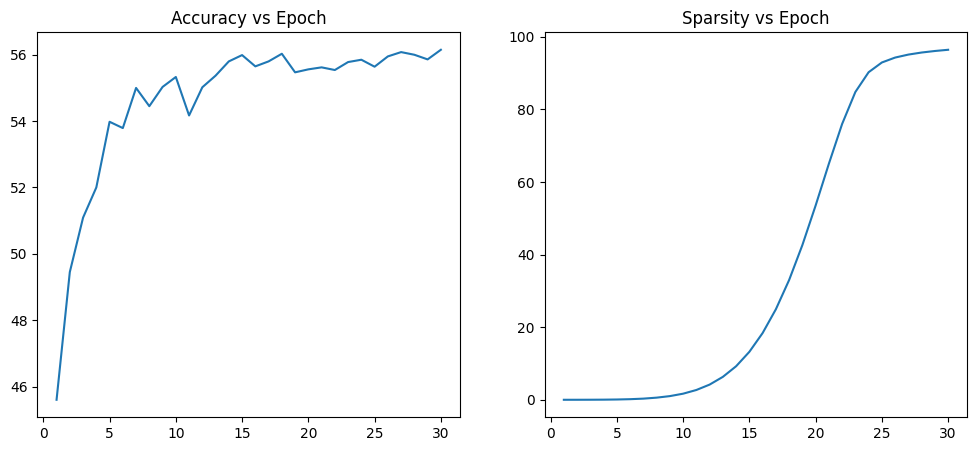


===== Training lambda = 0.001 =====
Epoch 1: Loss=786.1782, Acc=45.98, Sparsity=0.00
Epoch 2: Loss=652.3271, Acc=49.37, Sparsity=0.00
Epoch 3: Loss=529.0236, Acc=52.08, Sparsity=0.01
Epoch 4: Loss=421.5313, Acc=52.86, Sparsity=0.03
Epoch 5: Loss=332.5833, Acc=53.45, Sparsity=0.07
Epoch 6: Loss=261.9566, Acc=53.18, Sparsity=0.16
Epoch 7: Loss=207.2852, Acc=54.31, Sparsity=0.32
Epoch 8: Loss=165.3546, Acc=54.20, Sparsity=0.58
Epoch 9: Loss=133.1354, Acc=54.63, Sparsity=1.02
Epoch 10: Loss=108.1714, Acc=54.53, Sparsity=1.70
Epoch 11: Loss=88.6220, Acc=54.51, Sparsity=2.73
Epoch 12: Loss=73.1438, Acc=54.39, Sparsity=4.26
Epoch 13: Loss=60.7654, Acc=54.49, Sparsity=6.47
Epoch 14: Loss=50.7746, Acc=54.34, Sparsity=9.51
Epoch 15: Loss=42.6498, Acc=54.69, Sparsity=13.67
Epoch 16: Loss=35.9960, Acc=54.33, Sparsity=19.17
Epoch 17: Loss=30.5167, Acc=54.29, Sparsity=26.23
Epoch 18: Loss=25.9826, Acc=54.40, Sparsity=35.02
Epoch 19: Loss=22.2155, Acc=53.87, Sparsity=45.56
Epoch 20: Loss=19.0746, Ac

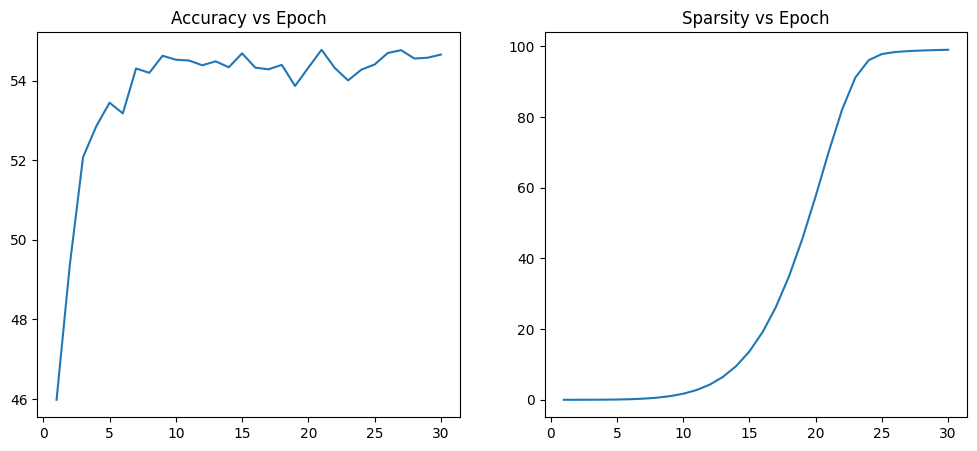


===== Training lambda = 0.002 =====
Epoch 1: Loss=1571.4847, Acc=45.53, Sparsity=0.00
Epoch 2: Loss=1303.8601, Acc=50.17, Sparsity=0.00
Epoch 3: Loss=1057.1501, Acc=51.90, Sparsity=0.01
Epoch 4: Loss=842.0149, Acc=53.11, Sparsity=0.03
Epoch 5: Loss=663.9550, Acc=53.34, Sparsity=0.08
Epoch 6: Loss=522.5571, Acc=54.12, Sparsity=0.17
Epoch 7: Loss=413.0758, Acc=53.99, Sparsity=0.32
Epoch 8: Loss=329.1095, Acc=54.39, Sparsity=0.58
Epoch 9: Loss=264.5810, Acc=53.47, Sparsity=1.02
Epoch 10: Loss=214.5776, Acc=54.16, Sparsity=1.70
Epoch 11: Loss=175.4150, Acc=54.00, Sparsity=2.75
Epoch 12: Loss=144.4054, Acc=53.75, Sparsity=4.29
Epoch 13: Loss=119.5992, Acc=53.40, Sparsity=6.52
Epoch 14: Loss=99.5730, Acc=52.94, Sparsity=9.62
Epoch 15: Loss=83.2787, Acc=53.62, Sparsity=13.84
Epoch 16: Loss=69.9308, Acc=53.22, Sparsity=19.45
Epoch 17: Loss=58.9321, Acc=53.26, Sparsity=26.63
Epoch 18: Loss=49.8255, Acc=53.12, Sparsity=35.66
Epoch 19: Loss=42.2548, Acc=52.70, Sparsity=46.57
Epoch 20: Loss=35.93

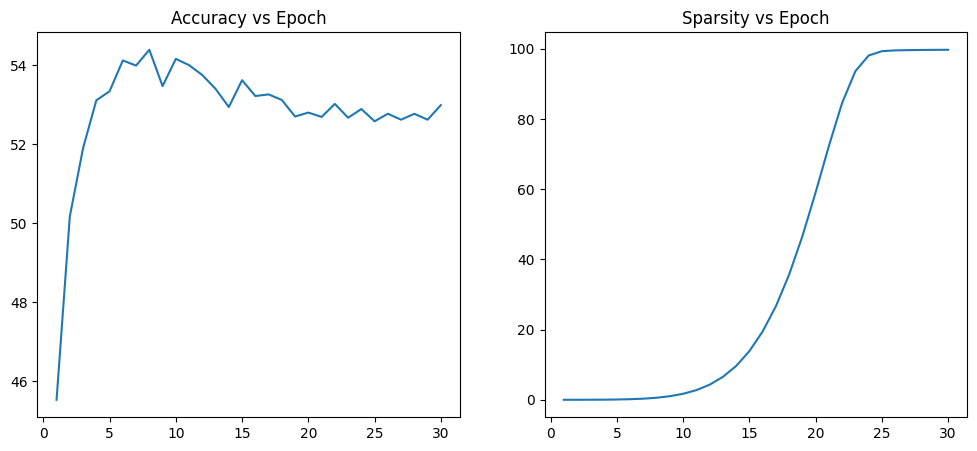

In [17]:
experiments = [1e-5, 1e-4, 5e-4, 1e-3, 2e-3]

all_results = []

for lambda_ in experiments:
    print(f"\n===== Training lambda = {lambda_} =====")
    
    model, logs = train_model(lambda_, epochs=30)
    
    acc = logs["accuracy"][-1]
    sparsity = logs["sparsity"][-1]
    
    print(f"Final Accuracy: {acc:.2f}%")
    print(f"Final Sparsity: {sparsity:.2f}%")
    
    # Save logs
    save_logs(logs, SAVE_PATH + f"logs_lambda_{lambda_}.json")
    
    # Save model
    torch.save(model.state_dict(), SAVE_PATH + f"model_lambda_{lambda_}.pth")
    
    # Plot
    plot_logs(logs, SAVE_PATH + f"plot_lambda_{lambda_}.png")
    
    all_results.append((lambda_, acc, sparsity))

In [18]:
print("\nFinal Results:")
print("Lambda\t\tAccuracy\tSparsity")

for r in all_results:
    print(f"{r[0]:.0e}\t\t{r[1]:.2f}%\t\t{r[2]:.2f}%")


Final Results:
Lambda		Accuracy	Sparsity
1e-05		54.14%		17.33%
1e-04		56.21%		68.91%
5e-04		56.15%		96.43%
1e-03		54.66%		99.07%
2e-03		52.99%		99.73%


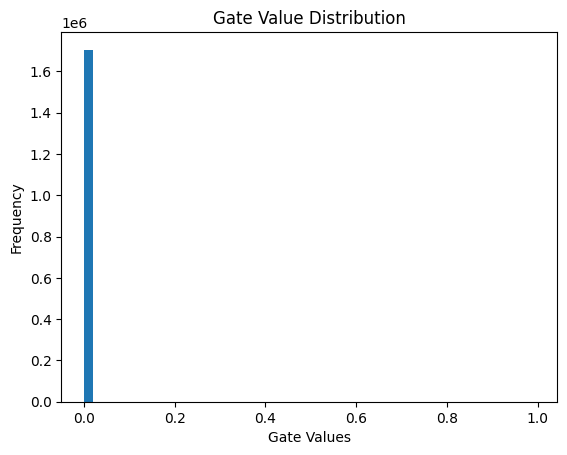

In [19]:
plot_gate_distribution(model)